# Config

In [3]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import pathlib
import ml_collections
import pandas as pd

OUT_DIR = pathlib.Path("C:\\Users\\pol12\\Desktop\\Universitat\\MAMME\\TFM\\tfm-ecoRL\\output")

In [ ]:
train_config = ml_collections.ConfigDict()

train_config.phase = 'train'

# Saving
train_config.path = './'
train_config.params_filename = 'my_trained_agent_independent_arms'

# Training
train_config.random_seed = 42
train_config.num_workers = 1
train_config.num_evaluators = 1
train_config.eval_every_steps = 20_000*10
train_config.num_eval_episodes = 400

# Environment
train_config.environment = ml_collections.ConfigDict()
train_config.environment.env_name = "bandit"
train_config.environment.steps_per_episode = int(100)
train_config.environment.reward_structure = "dependent_e" # "independent", "dependent_{u,e,m,h}"

# Agent
train_config.agent = ml_collections.ConfigDict()
train_config.agent.total_training_steps = int(100*20_000)
train_config.agent.random_seed = 42
train_config.agent.num_lstm_units = 48
train_config.agent.learning_rate_start = 3e-4
train_config.agent.learning_rate_end = 0.0
train_config.agent.gamma = 0.9
train_config.agent.v_loss_coef = 0.05
train_config.agent.e_loss_coef_start = 1.0
train_config.agent.e_loss_coef_end = 0.0
train_config.agent.max_unroll_steps = 200
train_config.agent.global_norm_grad_clip = 50.0

#%% Logging
train_config.log_every_steps = int(100*2)

# Training

In [6]:
from bandits.bandit_environments import create_env
from bandits.agents_2 import create_agent
from bandits.logger import create_logger

# Set random seed
np.random.seed(train_config.random_seed)

# Initialize environment
env = create_env(train_config.environment)
observation = env.reset() # [0,0,0]

# Initialize agent
agent = create_agent(observation=observation, num_actions=env.num_actions, agent_config=train_config.agent)

# Initialize logger
logger = create_logger(logger_name='bandit', config=train_config, log_to_console=True)

# Initialize LSTM recurrent state to zeros.
initial_lstm_state = agent.get_initial_lstm_state()
lstm_state = initial_lstm_state

# --- Main training loop (content for AKeAf77n4vIV, with PyTorch adaptations) ---
step, episode, loss_val = 0, 0, 0.0 # Initialize loss_val to a float
while step < train_config.agent.total_training_steps:
    # Get an action and step the environment with the agent's action
    # agent.get_action returns action (scalar int), pi_out (tensor), v_out (tensor), new_lstm_state (tuple of tensors), lstm_output (tensor)
    action, pi_out, v_out, new_lstm_state, _ = agent.get_action(observation, lstm_state)
    next_observation, reward, done, info = env.step(action)

    # Save experience in a buffer
    agent.buffer.append(
        obs=observation,
        action=action,
        reward=reward,
        next_obs=next_observation,
        done=done,
        lstm_state=lstm_state,
    )

    observation = next_observation
    lstm_state = new_lstm_state

    # Update agent parameters if an episode is done, or
    # if the agent experience buffer == max_unroll_steps
    # agent.update returns loss (scalar float), grads (dict), num_steps (int)
    current_loss, grads, num_steps_updated = agent.update(done, update_params=True)
    if current_loss is not None:
        loss_val = current_loss # Update loss_val if a loss was calculated

    # Log performance
    logger.log_step(
        global_step=step,
        worker_step=step,
        reward=reward,
        info=info,
        loss=loss_val, # Use the last calculated loss value
        entropy_coef=agent.e_loss_coef,
        action=action, # action is already a scalar int from model_step
        next_observation=next_observation, # This is a dict with np.ndarray, as expected by the logger
        arms_proba = env._arm_probs, # This is already a numpy array
    )

    step += 1

    # If done, reset the environment and LSTM state
    if done:
        episode += 1
        done = False
        lstm_state = agent.get_initial_lstm_state() # Get new initial LSTM state on correct device
        observation = env.reset()

print('Done training!')

Global step:	0	| Worker step:	0	| T:	0.00	| Mean Reward:	0.0000	| Entropy coef:	1.0000	| Loss:	0.00000	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 0.])}	|
Global step:	200	| Worker step:	200	| T:	0.12	| Mean Reward:	0.5150	| Entropy coef:	0.9998	| Loss:	-0.29656	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 0.])}	|
Global step:	400	| Worker step:	400	| T:	0.11	| Mean Reward:	0.4750	| Entropy coef:	0.9996	| Loss:	-0.29302	| Action:	1	| Next observation:	{'vector_input': array([0., 1., 0.])}	|
Global step:	600	| Worker step:	600	| T:	0.11	| Mean Reward:	0.4750	| Entropy coef:	0.9994	| Loss:	-0.33409	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 1.])}	|
Global step:	800	| Worker step:	800	| T:	0.11	| Mean Reward:	0.5750	| Entropy coef:	0.9992	| Loss:	-0.28458	| Action:	1	| Next observation:	{'vector_input': array([0., 1., 1.])}	|
Global step:	1000	| Worker step:	1000	| T:	0.11	| Mean Reward:	0.5000	| Entropy coef:	0.9990	| Loss:	-0.3

In [7]:
#@title Save model params and config after training
results = {
    "params": agent,
    "config": train_config.to_dict(),
    "training_df": logger.df,
}

# model_params_name = train_config.params_filename
model_params_name = train_config.environment.reward_structure
with open(OUT_DIR / 'bandit_models' / f'{model_params_name}.pkl', 'wb') as fp:
    pickle.dump([results], fp)
print("Saved parameters.")

Saved parameters.


In [8]:
# For running all together
for reward_structure in ["independent", "dependent_u", "dependent_m", "dependent_h"]:
    train_config.environment.reward_structure = reward_structure
    # Set random seed
    np.random.seed(train_config.random_seed)

    # Initialize environment
    env = create_env(train_config.environment)
    observation = env.reset() # [0,0,0]

    # Initialize agent
    agent = create_agent(observation=observation, num_actions=env.num_actions, agent_config=train_config.agent)

    # Initialize logger
    logger = create_logger(logger_name='bandit', config=train_config, log_to_console=True)

    # Initialize LSTM recurrent state to zeros.
    initial_lstm_state = agent.get_initial_lstm_state()
    lstm_state = initial_lstm_state

    # --- Main training loop (content for AKeAf77n4vIV, with PyTorch adaptations) ---
    step, episode, loss_val = 0, 0, 0.0 # Initialize loss_val to a float
    while step < train_config.agent.total_training_steps:
        # Get an action and step the environment with the agent's action
        # agent.get_action returns action (scalar int), pi_out (tensor), v_out (tensor), new_lstm_state (tuple of tensors), lstm_output (tensor)
        action, pi_out, v_out, new_lstm_state, _ = agent.get_action(observation, lstm_state)
        next_observation, reward, done, info = env.step(action)

        # Save experience in a buffer
        agent.buffer.append(
            obs=observation,
            action=action,
            reward=reward,
            next_obs=next_observation,
            done=done,
            lstm_state=lstm_state,
        )

        observation = next_observation
        lstm_state = new_lstm_state

        # Update agent parameters if an episode is done, or
        # if the agent experience buffer == max_unroll_steps
        # agent.update returns loss (scalar float), grads (dict), num_steps (int)
        current_loss, grads, num_steps_updated = agent.update(done, update_params=True)
        if current_loss is not None:
            loss_val = current_loss # Update loss_val if a loss was calculated

        # Log performance
        logger.log_step(
            global_step=step,
            worker_step=step,
            reward=reward,
            info=info,
            loss=loss_val, # Use the last calculated loss value
            entropy_coef=agent.e_loss_coef,
            action=action, # action is already a scalar int from model_step
            next_observation=next_observation, # This is a dict with np.ndarray, as expected by the logger
            arms_proba = env._arm_probs, # This is already a numpy array
        )

        step += 1

        # If done, reset the environment and LSTM state
        if done:
            episode += 1
            done = False
            lstm_state = agent.get_initial_lstm_state() # Get new initial LSTM state on correct device
            observation = env.reset()

    print('Done training!')

    # Save model params and config after training
    results = {
        "params": agent,
        "config": train_config.to_dict(),
        "training_df": logger.df,
    }

    # model_params_name = train_config.params_filename
    model_params_name = train_config.environment.reward_structure
    with open(OUT_DIR / 'bandit_models' / f'{model_params_name}.pkl', 'wb') as fp:
        pickle.dump([results], fp)
    print("Saved parameters.")

Global step:	0	| Worker step:	0	| T:	0.00	| Mean Reward:	0.0050	| Entropy coef:	1.0000	| Loss:	0.00000	| Action:	1	| Next observation:	{'vector_input': array([0., 1., 1.])}	|
Global step:	200	| Worker step:	200	| T:	0.10	| Mean Reward:	0.6800	| Entropy coef:	0.9998	| Loss:	-0.20455	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 1.])}	|
Global step:	400	| Worker step:	400	| T:	0.09	| Mean Reward:	0.4450	| Entropy coef:	0.9996	| Loss:	-0.29022	| Action:	1	| Next observation:	{'vector_input': array([0., 1., 0.])}	|
Global step:	600	| Worker step:	600	| T:	0.11	| Mean Reward:	0.7550	| Entropy coef:	0.9994	| Loss:	-0.03791	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 1.])}	|
Global step:	800	| Worker step:	800	| T:	0.11	| Mean Reward:	0.8850	| Entropy coef:	0.9992	| Loss:	-0.05397	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 0.])}	|
Global step:	1000	| Worker step:	1000	| T:	0.10	| Mean Reward:	0.3900	| Entropy coef:	0.9990	| Loss:	-0.2

# Previous Code

In [50]:
# Main training loop
step, episode, loss = 0, 0, 0
while step < train_config.agent.total_training_steps:
    # Get an action and step the environment with the agent's action
    action, _, v_out, new_lstm_state, _ = agent.get_action(observation, lstm_state)
    next_observation, reward, done, info = env.step(action)

    # Save experience in a buffer
    agent.buffer.append(
        obs=observation,
        action=action,
        reward=reward,
        next_obs=next_observation,
        done=done,
        lstm_state=lstm_state,
    )

    observation = next_observation
    lstm_state = new_lstm_state

    # Log performance
    logger.log_step(
        global_step=step,
        worker_step=step,
        reward=reward,
        info=info,
        loss=loss,
        entropy_coef=agent.e_loss_coef,
        action=action,
        next_observation=next_observation, #([1., 0.], [1.])
        arms_proba = env._arm_probs,
    )

    # Update agent parameters if an episode is done, or
    # if the agent experience buffer == max_unroll_steps
    loss, grads, num_steps = agent.update(done, update_params=True)
    step += 1

    # If done, reset the environment and LSTM state
    if done:
        episode += 1
        done = False
        lstm_state = initial_lstm_state
        observation = env.reset()

print('Done training!')

Global step:	0	| Worker step:	0	| T:	1.87	| Mean Reward:	0.0050	| Entropy coef:	0.0000	| Loss:	0.00000	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 1.])}	|
Global step:	200	| Worker step:	200	| T:	2.44	| Mean Reward:	0.5150	| Entropy coef:	0.0000	| Loss:	0.37423	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 1.])}	|
Global step:	400	| Worker step:	400	| T:	0.12	| Mean Reward:	0.5200	| Entropy coef:	0.0000	| Loss:	0.40053	| Action:	1	| Next observation:	{'vector_input': array([0., 1., 0.])}	|
Global step:	600	| Worker step:	600	| T:	0.12	| Mean Reward:	0.5100	| Entropy coef:	0.0000	| Loss:	0.40023	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 1.])}	|
Global step:	800	| Worker step:	800	| T:	0.12	| Mean Reward:	0.5100	| Entropy coef:	0.0000	| Loss:	0.31271	| Action:	0	| Next observation:	{'vector_input': array([1., 0., 0.])}	|
Global step:	1000	| Worker step:	1000	| T:	0.12	| Mean Reward:	0.5700	| Entropy coef:	0.0000	| Loss:	0.39181	

KeyboardInterrupt: 

- Use Pytorch instead for more explicit model?
- No improvement by using GPU

In [51]:
#@title Save model params and config after training
results = {
    "params": agent.params,
    "config": train_config.to_dict(),
    "training_df": logger.df,
}

# model_params_name = train_config.params_filename
model_params_name = "dependent_u_undertrained_bandit"
with open(f'{model_params_name}.pkl', 'wb') as fp:
    pickle.dump([results], fp)
print("Saved parameters.")

Saved parameters.


# 3.Evaluation

In [ ]:
#@title Eval Config
eval_config = ml_collections.ConfigDict()

eval_config.phase = 'eval'

eval_config.num_workers = 0
eval_config.num_evaluators = 1

# Saving
eval_config.path = OUT_DIR / "independent_bandit.pkl"
eval_config.params_filename = eval_config.path.stem

# Evaluation
eval_config.random_seed = 42
eval_config.num_eval_episodes = 400
eval_config.log_dynamics = True

# Evaluation environment
eval_config.eval_environment = ml_collections.ConfigDict()
eval_config.eval_environment.env_name = "bandit_eval"
eval_config.eval_environment.steps_per_episode = int(100)
eval_config.eval_environment.reward_structure = "independent"

# Agent
eval_config.agent = ml_collections.ConfigDict()

# json.loads(eval_config.to_json_best_effort())

In [25]:
# Load trained agent
with open(eval_config.path, 'rb') as fp:
    training_results = pickle.load(fp)

params = training_results[0]['params']
training_config = training_results[0]['config']
agent_config = training_config['agent']
training_df = training_results[0]['training_df']

# Initialize evaluation environment.
eval_env = create_env(eval_config.eval_environment)
observation = eval_env.reset() #[0,0,0]

# Initialize agent (same as training) and set learning rate to 0
agent = create_agent(
    agent_config=agent_config,
    observation=observation,
    num_actions=eval_env.num_actions,
)

# Setup initial LSTM memory state.
initial_lstm_state = agent.get_initial_lstm_state()
lstm_state = initial_lstm_state

# Overwrite agent paramters with saved training parameters.
agent.params = params

In [55]:
#@title Evaluation loop
def evaluate_all_probs(eval_env, agent, verbose=False):
    """Evaluate agent on all arm probabilities from (0,100) to (100, 0)"""
    # Setup evaluation episodes to test the agent on.
    arm1_probs = np.arange(101)/100
    arm2_probs = 1. - arm1_probs

    num_episodes = len(arm1_probs)
    eval_episodes = np.arange(num_episodes)

    # Initialize data to save
    eval_actions = np.zeros((num_episodes, eval_env._steps_per_episode))
    eval_actions[:] = np.nan

    eval_regrets = np.zeros((num_episodes, eval_env._steps_per_episode))

    for (arm1_prob, arm2_prob, ep) in zip(arm1_probs, arm2_probs, eval_episodes):

        step = 0
        done = False
        lstm_state = initial_lstm_state
        observation = eval_env.reset(arm_probs=np.array([arm1_prob, arm2_prob]))

        # Maximal expected reward
        optimal_expected_reward = max(arm1_prob, arm2_prob)
        if verbose:
          print(f"Ep {ep}: max_exp_reward = {optimal_expected_reward}")

        while not done:
            action, pi_out, v_out, new_lstm_state, _ = agent.get_action(observation, lstm_state)
            next_observation, reward, done, info = eval_env.step(action)

            # Save data
            eval_actions[ep, step] = action

            # Calculate step regret
            chosen_arm_expected_reward = arm1_prob if action == 0 else arm2_prob
            step_regret = optimal_expected_reward - chosen_arm_expected_reward
            eval_regrets[ep, step] = step_regret

            observation = next_observation
            lstm_state = new_lstm_state
            step += 1


    # Compute metrics: cumulative regret R_T(b), R_T(b) mean and std_dev
    cumulative_regrets = np.cumsum(eval_regrets, axis=1)

    print("Done evaluation.")
    return eval_actions, eval_regrets, cumulative_regrets


def evaluate_mean_cum_regret(eval_env, agent, num_episodes, verbose=False):
    """Evaluate agent on all arm probabilities from (0,100) to (100, 0)"""
    # Setup evaluation episodes to test the agent on.
    eval_episodes = np.arange(num_episodes)

    # Initialize data to save
    eval_actions = np.zeros((num_episodes, eval_env._steps_per_episode))
    eval_actions[:] = np.nan

    eval_regrets = np.zeros((num_episodes, eval_env._steps_per_episode))

    for ep in eval_episodes:
        step = 0
        done = False
        lstm_state = initial_lstm_state
        observation = eval_env.reset()
        arm1_prob, arm2_prob = eval_env._arm_probs

        # Maximal expected reward
        optimal_expected_reward = max(arm1_prob, arm2_prob)
        if verbose:
            print(f"Ep {ep}: max_exp_reward = {optimal_expected_reward}")

        while not done:
            action, pi_out, v_out, new_lstm_state, _ = agent.get_action(observation, lstm_state)
            next_observation, reward, done, info = eval_env.step(action)

            # Save data
            eval_actions[ep, step] = action

            # Calculate step regret
            chosen_arm_expected_reward = arm1_prob if action == 0 else arm2_prob
            step_regret = optimal_expected_reward - chosen_arm_expected_reward
            eval_regrets[ep, step] = step_regret

            observation = next_observation
            lstm_state = new_lstm_state
            step += 1

    # Compute metrics: cumulative regret R_T(b), R_T(b) mean and std_dev
    cumulative_regrets = np.cumsum(eval_regrets, axis=1)

    # R_T(b) Mean and Standard error (for confidence interval)
    mean_cumulative_regret = np.mean(cumulative_regrets, axis=0)
    std_cumulative_regret = np.std(cumulative_regrets, axis=0)
    se_cumulative_regret = std_cumulative_regret / np.sqrt(num_episodes)

    print("Done evaluation.")
    return eval_actions, eval_regrets, cumulative_regrets, mean_cumulative_regret, std_cumulative_regret, se_cumulative_regret


eval_actions, eval_regrets, cumulative_regrets = evaluate_all_probs(eval_env, agent, verbose=False)
# print("evaluate_all_probs evaluated!")

eval_actions_cum_regret, eval_regrets_cum_regret, cumulative_regrets_cum_regret, mean_cumulative_regret, std_cumulative_regret, se_cumulative_regret = evaluate_mean_cum_regret(eval_env, agent, eval_config.num_eval_episodes, verbose=False)

Done evaluation.


<Axes: title={'center': 'Testing: Independent'}, xlabel='Trial #', ylabel='Cumulative Regret'>

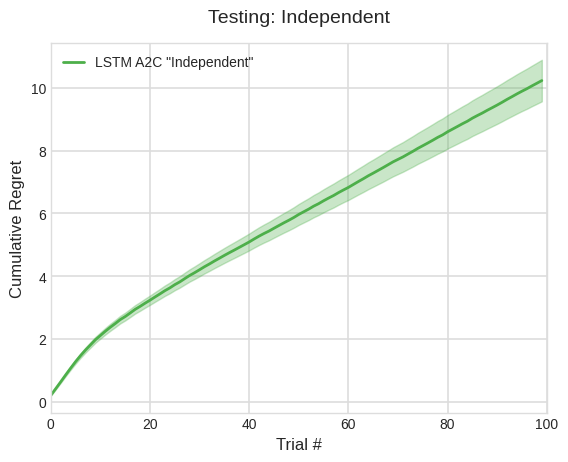

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def plot_data_with_uncertainty(x, mean, sd, sem, color='#4daf4a', label='LSTM A2C "Independent"'):
    """
    Plots the mean line with shaded regions for SD and SEM.
    Frame size set to 4:1 ratio (400x100 equivalent).
    """
    # Plot the primary line (matching the LSTM A2C style)
    plt.plot(x, mean, color=color, label=label, linewidth=2)

    # Shade the uncertainty (matching the single band in the reference)
    plt.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.3)

    # Other lines
    # plt.plot(x, mean * 1.2, color='#555555', linestyle='--', linewidth=2, label='Gittins')
    # plt.plot(x, mean * 0.7, color='#888888', linestyle='--', linewidth=2, label='Thompson')
    # plt.plot(x, mean * 1.3, color='#bbbbbb', linestyle='--', linewidth=2, label='UCB')

    # Formatting to match the image
    plt.title("Testing: Independent", fontsize=14, pad=15)
    plt.xlabel("Trial #", fontsize=12)
    plt.ylabel("Cumulative Regret", fontsize=12)
    plt.xlim(0, 100) # Ensure X axis starts exactly at 0 like the image
    plt.legend(loc='upper left', frameon=False, handlelength=1.5)

    ax = plt.gca()
    return ax

plot_data_with_uncertainty(np.arange(0, len(mean_cumulative_regret)), mean_cumulative_regret, std_cumulative_regret, se_cumulative_regret)

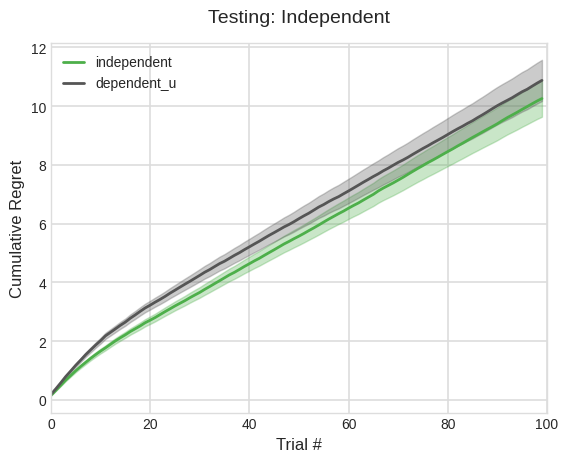

In [66]:
results_mean_cum_regret = {}
for env_type in ["independent", "dependent_u", "dependent_e", "dependent_m", "dependent_h"]:
    eval_env._reward_structure = env_type
    results_mean_cum_regret[env_type] = evaluate_mean_cum_regret(eval_env, agent, eval_config.num_eval_episodes, verbose=False)
    print(f"{env_type} evaluated \n")

color = ["#4daf4a", "#555555", "#888888", "#bbbbbb"]

# mean_cumulative_regret, std_cumulative_regret, se_cumulative_regret = results_mean_cum_regret["independent"]
for env_type in ["independent", "dependent_u", "dependent_e", "dependent_m", "dependent_h"]:
    eval_act, eval_reg, cum_reg, mean_cum_reg, std_cum_reg, se_cum_reg = results_mean_cum_regret[env_type]
    plot_data_with_uncertainty(np.arange(0, len(mean_cum_reg)), mean_cum_reg, std_cum_reg, se_cum_reg, label=env_type, color=color[i])


# 4.Visualization

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_with_rolling_mean_and_regression(
    df, x, y, window_size=10, title="Title of the graph", xlabel=None, ylabel=None,
    plot_size=(14, 7), grid=True, regression_line=True, alpha=0.3, rolling_mean_alpha=0.4,
    rolling_mean_color="blue", regression_line_style="--", regression_line_color="orange"
):
    """
    Plots a graph with the original data, rolling mean, and an optional regression line.

    Parameters:
    ------------
    df : DataFrame
        DataFrame containing the data to be plotted.

    x : str
        The column name for the x-axis data.

    y : str
        The column name for the y-axis data.

    window_size : int, optional, default=10
        The window size for calculating the rolling mean.

    title : str, optional, default="Title of the graph"
        Title for the plot.

    xlabel : str, optional
        Label for the x-axis. Defaults to the name of the x column.

    ylabel : str, optional
        Label for the y-axis. Defaults to the name of the y column.

    plot_size : tuple, optional, default=(14, 7)
        Size of the plot in inches (width, height).

    grid : bool, optional, default=True
        Whether to display the grid on the plot.

    regression_line : bool, optional, default=True
        Whether to include a linear regression line.

    alpha : float, optional, default=0.3
        Transparency for the original data points.

    rolling_mean_alpha : float, optional, default=0.4
        Transparency for the rolling mean line.

    rolling_mean_color : str, optional, default="blue"
        Color of the rolling mean line.

    regression_line_style : str, optional, default="--"
        Line style for the regression line.

    regression_line_color : str, optional, default="orange"
        Color of the regression line.
    """
    # Drop NaN values for x and y
    df = df.dropna(subset=[x, y])

    # Sort the DataFrame by the x column
    df = df.sort_values(by=x)

    # Calculate the rolling mean with the specified window size
    df["Rolling_Mean"] = df[y].rolling(window=window_size).mean()

    # Prepare for regression
    x_regression = np.array(pd.to_numeric(df[x]))
    y_regression = df[y].values
    mask = ~np.isnan(x_regression) & ~np.isnan(y_regression)  # Remove NaN values for regression
    x_regression = x_regression[mask]
    y_regression = y_regression[mask]

    # Perform linear regression
    if regression_line:
        slope, intercept = np.polyfit(x_regression, y_regression, 1)
        regression_line_values = slope * x_regression + intercept

    # Plot
    fig, ax = plt.subplots(figsize=plot_size)

    # Plot the original data points with transparency
    ax.plot(df[x], df[y], "-", alpha=alpha, label="Original Data")

    # Plot the rolling mean
    ax.plot(
        df[x],
        df["Rolling_Mean"],
        label=f"Rolling Mean (window={window_size})",
        color=rolling_mean_color,
        alpha=rolling_mean_alpha,
        linewidth=2,
    )

    # Plot the regression line if enabled
    if regression_line:
        ax.plot(
            df[x],
            regression_line_values,
            label="Regression Line",
            linestyle=regression_line_style,
            color=regression_line_color,
            linewidth=2,
        )

    # Customize labels and title
    ax.set_xlabel(xlabel if xlabel else x)
    ax.set_ylabel(ylabel if ylabel else y)
    ax.set_title(title, fontweight="bold", fontsize=16)

    # Add a legend
    ax.legend()

    # Show the grid if specified
    if grid:
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="gray", alpha=0.2)

    # Display the plot
    plt.show()

"""
#We build dataframe (UNCOMMENT FOR NOTEBOOK VISUALIZATION)
import numpy as np
x_data = np.linspace(-4, 4, 100) #set x values we will plot
y_data = np.sin(np.linspace(-4, 4, 100)) #set y values we will plot
df = pd.DataFrame({"time_variable": x_data, "plot_variable": y_data})
"""

'\n#We build dataframe (UNCOMMENT FOR NOTEBOOK VISUALIZATION)\nimport numpy as np\nx_data = np.linspace(-4, 4, 100) #set x values we will plot\ny_data = np.sin(np.linspace(-4, 4, 100)) #set y values we will plot\ndf = pd.DataFrame({"time_variable": x_data, "plot_variable": y_data})\n'

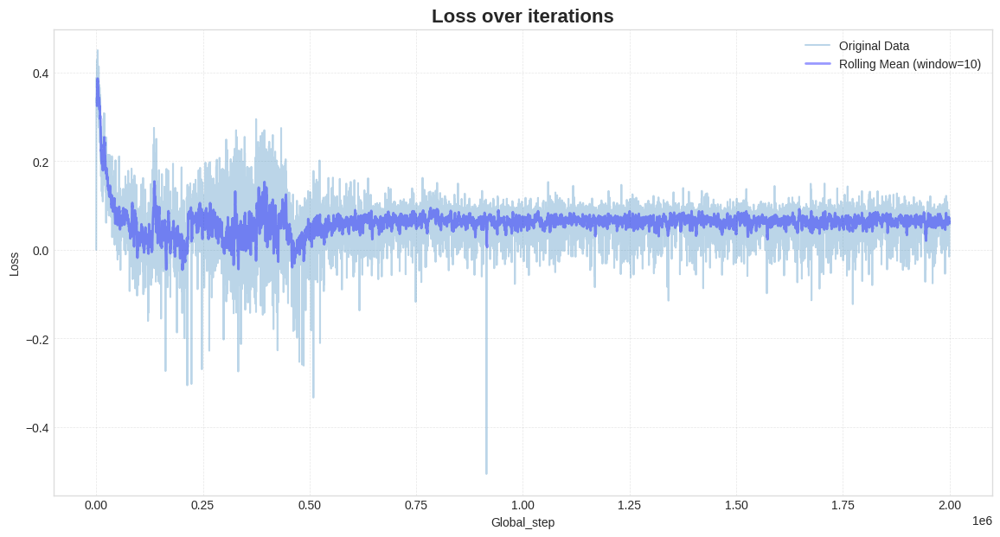

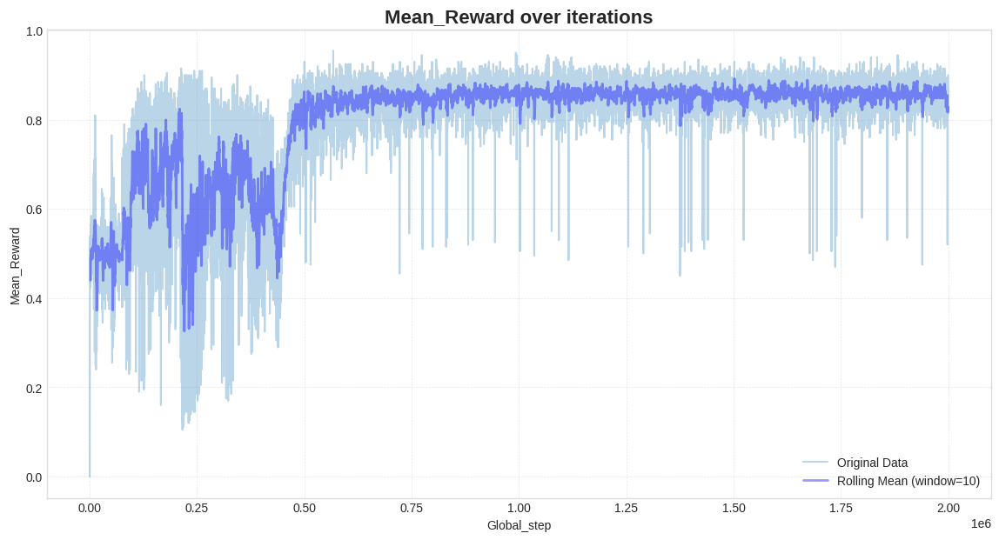

In [72]:
model_path = BASE_DIR / "dependent_e_bandit.pkl"

with open(model_path, 'rb') as fp:
    training_results = pickle.load(fp)

params = training_results[0]['params']
training_config = training_results[0]['config']
agent_config = training_config['agent']
training_df = training_results[0]['training_df']


plot_with_rolling_mean_and_regression(training_df, x="Global_step", y="Loss", regression_line=False, title="Loss over iterations")
plt.show()
plot_with_rolling_mean_and_regression(training_df, x="Global_step", y="Mean_Reward", regression_line=False, title="Mean_Reward over iterations")
plt.show()

In [40]:
# Auxiliary functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_action_results(data, tick_fontsize=16, label_fontsize=20):
    """Plot heatmap of action results"""
    # Setup custom legend.
    cmap_name = 'tab20c'
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    zero_color = cmap(0.)
    one_color = cmap(1.)
    patch1 = mpatches.Patch(color=zero_color, label='Arm 1')
    patch2 = mpatches.Patch(color=one_color, label='Arm 2')

    # Setup evaluation episodes to test the agent on.
    arm1_probs = np.arange(101)/100
    arm2_probs = 1. - arm1_probs

    num_episodes = len(arm1_probs)
    eval_episodes = np.arange(num_episodes)

    # Set yticks labels
    ytick_vals = [0, eval_episodes[int(len(eval_episodes)/2)], eval_episodes[-1]]
    ytick_labels = []
    for i in ytick_vals:
        cur_probs = str(int(arm1_probs[i]*100)) + ", " + str(int(arm2_probs[i]*100))
        ytick_labels.append(cur_probs)

    # Build plot
    fig = plt.figure(figsize=(8, 6))
    ax = plt.subplot()
    plt.imshow(data, cmap='tab20c', origin='lower')
    plt.yticks(
        ticks=ytick_vals,
        labels=ytick_labels,
        fontsize=tick_fontsize,
        )
    plt.xticks(
        ticks=[0, env._steps_per_episode],
        labels=[0, env._steps_per_episode],
        fontsize=tick_fontsize,
        )
    plt.xlabel("Trials", fontsize=label_fontsize)
    plt.ylabel("Arm win probabilities \n (Arm 1 %, Arm 2 %)", fontsize=label_fontsize)
    ax.spines[['right', 'top']].set_visible(False)
    plt.legend(handles=[patch1, patch2],
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              frameon=False,
              fontsize=label_fontsize,
              borderaxespad=0.,
              )
    plt.tight_layout()
    plt.show()

def plot_all_cum_regret(df, alpha=0.7):
    # 1. Set the specific aesthetic
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Liberation Sans"],
        "axes.edgecolor": "#DDDDDD",
        "grid.color": "#DDDDDD",
        "grid.linewidth": 1.2
    })

    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    # 2. Setup Gradient (RdBu as requested originally, or Viridis for clarity)
    norm = plt.Normalize(vmin=0, vmax=len(df)-1)
    sm = plt.cm.ScalarMappable(cmap='RdBu', norm=norm)

    # 3. Plotting
    for idx, row in df.iterrows():
        color = sm.to_rgba(idx)
        # We use a thinner line to match the high-density look of the reference
        ax.plot(row.values, color=color, alpha=alpha, linewidth=1.5)

    # 4. Replicating the Labels and Title from the image
    ax.set_title(r"$R_T(b)$ from Red (0,100) to Blue (100,0)", fontsize=14, fontweight='normal', pad=15)
    ax.set_xlabel("Trial #", fontsize=14)
    ax.set_ylabel("Cumulative Regret", fontsize=14)

    # 5. Formatting Ticks
    ax.tick_params(labelsize=14)
    ax.set_xlim(0, len(df.columns)) # Ensure it starts at 0 like the image

    # 6. The Legend/Colorbar
    # The image doesn't use a colorbar, it uses a legend.
    cbar = fig.colorbar(sm, ax=ax, aspect=30, pad=0.02)
    cbar.outline.set_visible(False)
    cbar.set_label('Row Index', size=12)

    for spine in ax.spines.values():
        spine.set_visible(True)

    plt.tight_layout()
    plt.show()


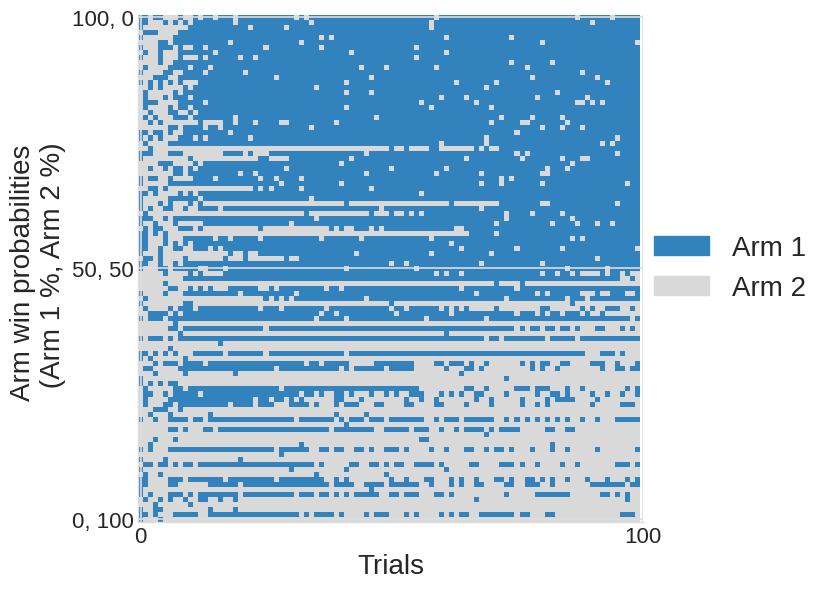

In [41]:


# Independent agent on Independent Eval env
plot_action_results(eval_actions)

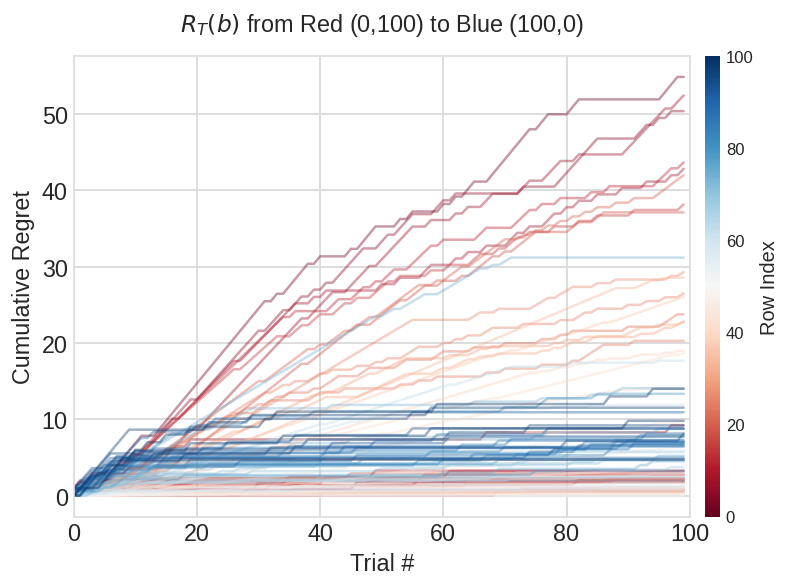

In [32]:
mean_cum_reg = pd.DataFrame(cumulative_regrets)

plot_all_cum_regret(mean_cum_reg, alpha=0.4)

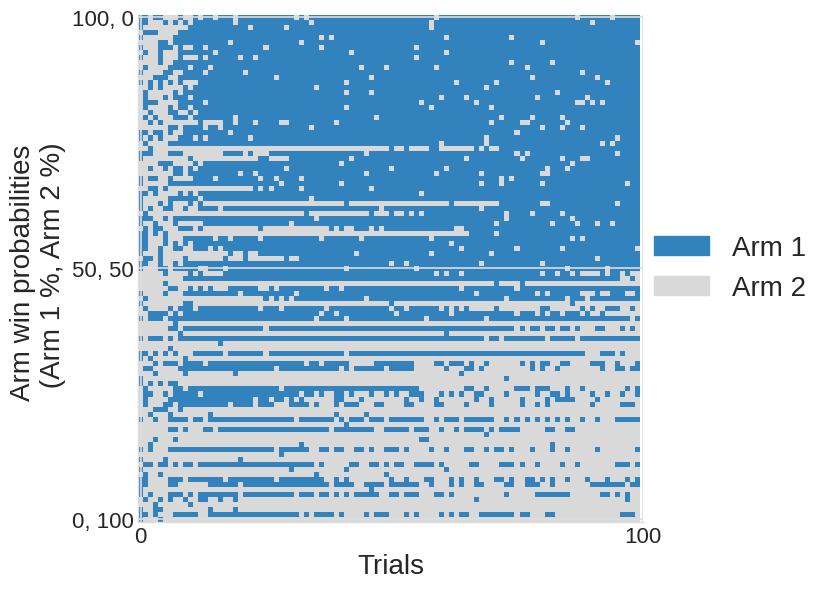

In [42]:
# Independent agent on Dependent Eval env
plot_action_results(eval_actions)

# play_env_as_human.ipynb

This is a Google Colab notebook to demo the meta-rl multi-armed bandit environment.

For more details, see the GitHub repository (https://github.com/nathanwispinski/meta-rl).

In [ ]:
#@title Import dependencies after install.
import numpy as np
import time
from IPython.display import display, clear_output
import ipywidgets as widgets

In [ ]:
#@title Create a config for the environment.
#@markdown Available `reward_structure` configs are: `independent`, and `correlated`.

steps_per_episode = 10 #@param {type:"integer"}
num_arms = 2 #@param {type:"integer"}
reward_structure = "correlated" #@param {type:"string"}
total_episodes = 10 #@param {type:"integer"}

env_config = {
    "steps_per_episode": steps_per_episode,
    "num_arms": num_arms,
    "reward_structure": reward_structure,
}

In [ ]:
#@title Create environment.
env = create_env(env_config=env_config)
valid_action_range = np.arange(env.num_actions)
observation = env.reset()

In [ ]:
#@title Play environment as a human.

output = widgets.Output()

# Make one button per bandit arm
num_arms = env_config['num_arms']
buttons = []
click_fns = []
for i in range(num_arms):
    arm_name = "Arm " + str(i + 1)
    button = widgets.Button(description=arm_name)
    def button_click(a, action=i):
        next_observation, reward, done, info = env.step(action)
        step = interactive_info['step']
        print(f'Step: {step}; Action: {action}; Reward: {reward}; {next_observation}')
        if done:
            interactive_info['step'] = 0
        else:
            interactive_info['step'] += 1
        interactive_info['observation'] = next_observation
        if done:
            print(f'Episode done. Arm win probs were: {env._arm_probs}')
            env.reset()
    buttons.append(button)
    click_fns.append(button_click)

for (button, click_fn) in zip(buttons, click_fns):
    button.on_click(click_fn)

# Make a clear history button
button_0 = widgets.Button(description="Clear history")
def button_0_click(b):
    clear_output()
    display(*buttons)
button_0.on_click(button_0_click)

interactive_info = {
    'step': 0,
    'observation': None,
    'next_observation': None,
    'reward': None,
    'done': None,
    'info': None,
    'action': None
    }

buttons.append(button_0)
buttons.append(output)

display(*buttons)

interactive_info['observation'] = env.reset()
print(interactive_info['observation'])


Button(description='Arm 1', style=ButtonStyle())

Button(description='Arm 2', style=ButtonStyle())

Button(description='Clear history', style=ButtonStyle())

Output()

{'vector_input': array([0., 0., 0.])}
Step: 0; Action: 0; Reward: 1.0; {'vector_input': array([1., 0., 1.])}
Step: 1; Action: 0; Reward: 1.0; {'vector_input': array([1., 0., 1.])}
Step: 2; Action: 0; Reward: 0.0; {'vector_input': array([1., 0., 0.])}
Step: 3; Action: 0; Reward: 1.0; {'vector_input': array([1., 0., 1.])}
Step: 4; Action: 0; Reward: 0.0; {'vector_input': array([1., 0., 0.])}
Step: 5; Action: 0; Reward: 1.0; {'vector_input': array([1., 0., 1.])}
Step: 6; Action: 0; Reward: 1.0; {'vector_input': array([1., 0., 1.])}
Step: 7; Action: 0; Reward: 0.0; {'vector_input': array([1., 0., 0.])}
Step: 8; Action: 0; Reward: 0.0; {'vector_input': array([1., 0., 0.])}
Step: 9; Action: 0; Reward: 0.0; {'vector_input': array([1., 0., 0.])}
Episode done. Arm win probs were: [0.71110489 0.28889511]
Step: 0; Action: 0; Reward: 1.0; {'vector_input': array([1., 0., 1.])}
